In [10]:
from data_preprocessing import features_train, labels_train, features_test, labels_test, feature_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from pandas import DataFrame
import matplotlib.pyplot as plt

In [2]:
model = RandomForestClassifier(criterion="entropy", n_estimators=150, max_features=12, max_depth=12, random_state=42, class_weight="balanced")
model.fit(features_train, labels_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",12
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [3]:
print([tree.tree_.max_depth for tree in model.estimators_])

[11, 11, 9, 12, 11, 10, 11, 10, 12, 11, 10, 10, 11, 12, 12, 11, 11, 11, 10, 10, 10, 10, 11, 11, 12, 10, 11, 10, 12, 11, 11, 11, 11, 9, 11, 10, 11, 11, 11, 10, 11, 12, 10, 10, 10, 12, 10, 11, 11, 12, 11, 12, 11, 11, 10, 10, 11, 10, 10, 11, 12, 12, 10, 10, 9, 12, 12, 10, 11, 10, 10, 11, 12, 11, 12, 10, 11, 12, 11, 10, 10, 11, 10, 10, 10, 11, 11, 10, 10, 10, 11, 10, 10, 11, 12, 12, 10, 12, 10, 10, 10, 10, 12, 10, 12, 10, 12, 10, 11, 10, 10, 10, 10, 10, 10, 12, 11, 12, 11, 10, 9, 11, 11, 10, 10, 12, 10, 12, 11, 12, 11, 11, 12, 11, 12, 10, 11, 11, 12, 10, 10, 11, 12, 10, 11, 11, 11, 11, 12, 10]


In [4]:
y_train_pred = model.predict(features_train)
y_test_pred = model.predict(features_test)

In [5]:
print("Benchmark:", accuracy_score(labels_train, y_train_pred))
print("Accuracy:", accuracy_score(labels_test, y_test_pred))

Benchmark: 1.0
Accuracy: 0.916


In [6]:
#Loop through all the labels from 1 to 4
for class_value in range(0, 4):
    #The predicted and actual binary labels for each class label will be stored in the following lists
    predicted_labels = []
    actual_labels = []

    #Go through both the predicted labels and actual labels
    for index in range(len(y_test_pred)):
        #If the label is the one we are currently concerned about,
        # add it to the predicted labels list as a 1
        if y_test_pred[index] == class_value:
            predicted_labels.append(1)

        #Otherwise, since it is not what we're looking for, add it to the predicted labels as a 0
        else:
            predicted_labels.append(0)

        #Do the same thing as above, but with the actual labels
        #pd.Series.iloc[] does the same thing to a pandas Series as indexing through a list
        if labels_test.iloc[index] == class_value:
            actual_labels.append(1)
        else:
            actual_labels.append(0)

    #Get the accuracy, precision, recall, f1 and roc-auc score for the current class label
    accuracy = accuracy_score(actual_labels, predicted_labels)
    precision = precision_score(actual_labels, predicted_labels)
    recall = recall_score(actual_labels, predicted_labels)
    f1 = f1_score(actual_labels, predicted_labels)
    roc_auc = roc_auc_score(actual_labels, predicted_labels)

    #Print all the metrics for the current class label, rounding them to 2 significant figures
    print(f"Accuracy score for class label {class_value}: {accuracy:.2f}")
    print(f"Precision score for class label {class_value}: {precision:.2f}")
    print(f"Recall score for class label {class_value}: {recall:.2f}")
    print(f"F1 score for class label {class_value}: {f1:.2f}")
    print(f"ROC-AUC score class label {class_value}: {roc_auc:.2f}")
    print()


Accuracy score for class label 0: 0.97
Precision score for class label 0: 0.95
Recall score for class label 0: 0.95
F1 score for class label 0: 0.95
ROC-AUC score class label 0: 0.97

Accuracy score for class label 1: 0.95
Precision score for class label 1: 0.85
Recall score for class label 1: 0.93
F1 score for class label 1: 0.89
ROC-AUC score class label 1: 0.94

Accuracy score for class label 2: 0.94
Precision score for class label 2: 0.93
Recall score for class label 2: 0.82
F1 score for class label 2: 0.87
ROC-AUC score class label 2: 0.90

Accuracy score for class label 3: 0.97
Precision score for class label 3: 0.93
Recall score for class label 3: 0.96
F1 score for class label 3: 0.94
ROC-AUC score class label 3: 0.97



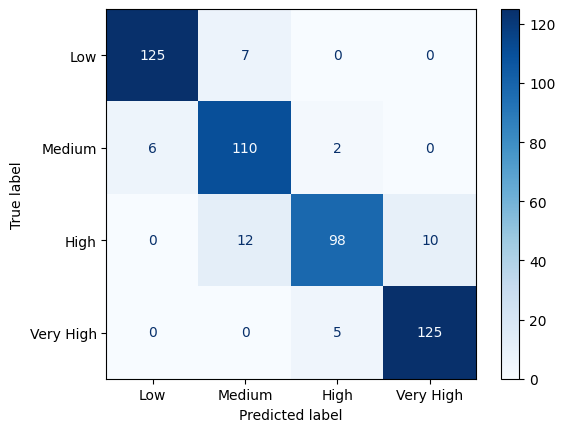

In [13]:
#Create confusion matrix in numpy array
conf_matrix = confusion_matrix(labels_test, y_test_pred)

#Create display using ConfusionMatrixDisplay, which will handle the majority of the formatting
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Low", "Medium", "High", "Very High"])

#Change colour display to Blue
display.plot(cmap=plt.cm.Blues)
plt.show()

In [7]:
#Get the feature names
feature_names = feature_matrix.columns

#Get the importance of each feature to the model
feature_importances = model.feature_importances_

#Combine the features and their importances into a pandas DataFrame
most_important_features = DataFrame({
    "Features": feature_names,
    "Importance": feature_importances
})

#Print the top 5 features based on importance
#ascending=False ensures the DataFrame is sorted into descending order
#.head(5) takes only the first 5 rows
print(most_important_features.sort_values("Importance", ascending=False).head(5))

         Features  Importance
13            ram    0.681383
0   battery_power    0.102458
11      px_height    0.065244
12       px_width    0.058422
8       mobile_wt    0.016272
